## **Clone the repo**

In [14]:
!git clone https://github.com/IT25100310/Indoor-Plant-Disease-Dataset.git

Cloning into 'Indoor-Plant-Disease-Dataset'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 10 (delta 0), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (10/10), done.


In [15]:
!ls

Indoor-Plant-Disease-Dataset


In [19]:
%cd Indoor-Plant-Disease-Dataset

/content/Indoor-Plant-Disease-Dataset


In [10]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [ ]:

!git config --global user.email "it25100310@my.sliit.lk"
!git config --global user.name "D M L M Bandara-IT25100310"

!git checkout -b IT25100310-missing-data

!git status

!git add notebooks/Indoor-Plant-Disease-Dataset.ipynb

!git commit -m "Scalling/Normalization"


fatal: a branch named 'IT25100310-missing-data' already exists
On branch IT25100310-missing-data
nothing to commit, working tree clean
fatal: pathspec 'notebooks/Indoor-Plant-Disease-Dataset.ipynb' did not match any files
On branch IT25100310-missing-data
nothing to commit, working tree clean


# **start from the latest [main]**

In [21]:
%cd /content/Indoor-Plant-Disease-Dataset
!find . -name "*.ipynb"

/content/Indoor-Plant-Disease-Dataset


In [22]:
!find /content/Indoor-Plant-Disease-Dataset -name "*.ipynb"

# Confirm you're in the right place and it's a real git repo

In [23]:
!pwd
!git status

/content/Indoor-Plant-Disease-Dataset
On branch IT25100310-missing-data
nothing to commit, working tree clean


# **Create your branch**

In [24]:
!git checkout -b IT25100310-missing-data

fatal: a branch named 'IT25100310-missing-data' already exists


# **Create the notebooks folder and notebook file**

In [25]:
!mkdir -p notebooks

# **Check Status again**

In [26]:
!git status

On branch IT25100310-missing-data
nothing to commit, working tree clean


# **Import kaggle.json**

In [29]:
import json

kaggle_creds = {
    "username": "lasithwxn",
    "key": "KGAT_0c7fa6b60ed650ae9e53e8ffd82c669e"
}

import os
os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_creds, f)

!chmod 600 /root/.kaggle/kaggle.json
!pip install -q kaggle

In [30]:
!kaggle datasets download -d aditisalvi04/indoor-plant-disease-dataset

Dataset URL: https://www.kaggle.com/datasets/aditisalvi04/indoor-plant-disease-dataset
License(s): MIT
100% 7.79G/7.79G [01:34<00:00, 88.3MB/s]



# **unzip**

In [32]:
!mkdir -p /content/data/raw
!unzip -q indoor-plant-disease-dataset.zip -d /content/data/raw/

In [34]:
#verify

!ls /content/data/raw/

'Final Dataset'


# **Normalization/Scaling**

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ---- 1. Load dataset path ----
data_path = "/content/data/raw/"
classes = os.listdir(data_path)
print("Classes found:", classes)
print("Number of classes:", len(classes))

Classes found: ['Final Dataset']
Number of classes: 1


In [38]:
# ============================================
# IT25100310 - Normalization / Scaling
# Plant Disease Dataset - Image Preprocessing
# ============================================

# ---- 2. Pick a sample image to demonstrate scaling ----
sample_class = classes[0]
sample_folder = os.path.join(data_path, sample_class)
sample_image_name = os.listdir(sample_folder)[0]
sample_image_path = os.path.join(sample_folder, sample_image_name)

img = cv2.imread(sample_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Original shape:", img.shape)
print("Original pixel range:", img.min(), "-", img.max())

plt.imshow(img)
plt.title(f"Original Sample: {sample_class}")
plt.axis('off')
plt.show()

# ---- 3. Resize to a consistent size (required before scaling) ----
IMG_SIZE = 224
img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
print("Resized shape:", img_resized.shape)

# ---- 4. Min-Max Scaling (0 to 1) ----
img_scaled = img_resized / 255.0
print("Min-Max Scaled pixel range:", img_scaled.min(), "-", img_scaled.max())

# ---- 5. Standardization (Z-score: mean=0, std=1) ----
mean = img_resized.mean()
std = img_resized.std()
img_standardized = (img_resized - mean) / std
print("Standardized pixel mean:", round(img_standardized.mean(), 4))
print("Standardized pixel std:", round(img_standardized.std(), 4))

# ---- 6. EDA Visualization: Pixel Intensity Distribution Before vs After Scaling ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(img_resized.ravel(), bins=50, color='orange')
axes[0].set_title("Original (0-255)")
axes[0].set_xlabel("Pixel Value")
axes[0].set_ylabel("Frequency")

axes[1].hist(img_scaled.ravel(), bins=50, color='green')
axes[1].set_title("Min-Max Scaled (0-1)")
axes[1].set_xlabel("Pixel Value")

axes[2].hist(img_standardized.ravel(), bins=50, color='blue')
axes[2].set_title("Standardized (mean=0, std=1)")
axes[2].set_xlabel("Pixel Value")

plt.tight_layout()

# ---- 7. Save visualization to results folder ----
os.makedirs("/content/Indoor-Plant-Disease-Dataset/results/eda_visualizations", exist_ok=True)
plt.savefig("/content/Indoor-Plant-Disease-Dataset/results/eda_visualizations/pixel_scaling_comparison.png")
plt.show()

print("\nEDA visualization saved successfully.")

error: OpenCV(5.0.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [40]:
#debug
print("Sample folder:", sample_folder)
print("Files in folder:", os.listdir(sample_folder)[:10])
print("Chosen file:", sample_image_name)
print("Full path:", sample_image_path)
print("Path exists:", os.path.exists(sample_image_path))

Sample folder: /content/data/raw/Final Dataset
Files in folder: ['Aloe Vera', 'Turmeric', 'Hibiscus', 'Money Plant', 'Rose', 'Chrysanthemum']
Chosen file: Aloe Vera
Full path: /content/data/raw/Final Dataset/Aloe Vera
Path exists: True


# **getting structure**

In [42]:
for root, dirs, files in os.walk(data_path):
    depth = root[len(data_path):].count(os.sep)
    indent = "  " * depth
    print(f"{indent}{os.path.basename(root) or root}/  ({len(files)} files, {len(dirs)} subdirs)")
    if depth > 2:  # don't spam the whole tree
        dirs[:] = []

/content/data/raw//  (0 files, 1 subdirs)
Final Dataset/  (0 files, 6 subdirs)
  Aloe Vera/  (0 files, 5 subdirs)
    Aloe_Rust/  (1759 files, 0 subdirs)
    Aloe_Sunburn/  (3343 files, 0 subdirs)
    Aloe_Anthracnose/  (3267 files, 0 subdirs)
    Aloe_Leaf_Spot/  (3295 files, 0 subdirs)
    Aloe_Healthy/  (4654 files, 0 subdirs)
  Turmeric/  (0 files, 5 subdirs)
    Turmeric_Blotch/  (1904 files, 0 subdirs)
    Turmeric_Leaf_Necrosis/  (812 files, 0 subdirs)
    Turmeric_Aphid_Infestation/  (847 files, 0 subdirs)
    Turmeric_Leaf_Spot/  (919 files, 0 subdirs)
    Turmeric_Healthy/  (1806 files, 0 subdirs)
  Hibiscus/  (0 files, 4 subdirs)
    Hibiscus_Healthy/  (1200 files, 0 subdirs)
    Hibiscus_Scorch/  (1200 files, 0 subdirs)
    Hibiscus_Necrosis/  (1200 files, 0 subdirs)
    Hibiscus_Blight/  (1200 files, 0 subdirs)
  Money Plant/  (0 files, 4 subdirs)
    Money_Plant_Manganese_Toxicity/  (596 files, 0 subdirs)
    Money_Plant_Bacterial_Wilt/  (576 files, 0 subdirs)
    Money_P

In [43]:
data_path = "/content/data/raw/Final Dataset"

# Build the real class list: one entry per disease/health folder, two levels deep
class_folders = {}  # class_name -> full folder path
for plant in os.listdir(data_path):
    plant_path = os.path.join(data_path, plant)
    if not os.path.isdir(plant_path):
        continue
    for disease_folder in os.listdir(plant_path):
        full_path = os.path.join(plant_path, disease_folder)
        if os.path.isdir(full_path):
            class_folders[disease_folder] = full_path

classes = sorted(class_folders.keys())
print(f"Total classes: {len(classes)}")
print(classes)

Total classes: 29
['Aloe_Anthracnose', 'Aloe_Healthy', 'Aloe_Leaf_Spot', 'Aloe_Rust', 'Aloe_Sunburn', 'Chrysanthemum_Bacterial_Leaf_Spot', 'Chrysanthemum_Healthy', 'Chrysanthemum_Septoria_Leaf_Spot', 'Hibiscus_Blight', 'Hibiscus_Healthy', 'Hibiscus_Necrosis', 'Hibiscus_Scorch', 'Money_Plant_Bacterial_Wilt', 'Money_Plant_Chlorosis', 'Money_Plant_Healthy', 'Money_Plant_Manganese_Toxicity', 'Rose_Black_Spot', 'Rose_Downy_Mildew', 'Rose_Healthy', 'Rose_Insect_Damage', 'Rose_Mosaic_Virus', 'Rose_Powdery_Mildew', 'Rose_Rust', 'Rose_Yellow_Mosaic_Virus', 'Turmeric_Aphid_Infestation', 'Turmeric_Blotch', 'Turmeric_Healthy', 'Turmeric_Leaf_Necrosis', 'Turmeric_Leaf_Spot']


In [44]:
sample_class = classes[0]
sample_folder = class_folders[sample_class]

valid_ext = ('.jpg', '.jpeg', '.png', '.bmp')
image_files = [f for f in os.listdir(sample_folder) if f.lower().endswith(valid_ext)]
sample_image_path = os.path.join(sample_folder, image_files[0])

img = cv2.imread(sample_image_path)
if img is None:
    raise ValueError(f"Failed to load image at {sample_image_path}")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Original shape:", img.shape)
print("Original pixel range:", img.min(), "-", img.max())

Original shape: (220, 208, 3)
Original pixel range: 0 - 245


# **visualization**

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

sns.set_style("whitegrid")

IMG_SIZE = 224
img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
print("Resized shape:", img_resized.shape)

img_scaled = img_resized / 255.0
print("Min-Max Scaled pixel range:", img_scaled.min(), "-", img_scaled.max())

mean = img_resized.mean()
std = img_resized.std()
img_standardized = (img_resized - mean) / std
print("Standardized pixel mean:", round(img_standardized.mean(), 4))
print("Standardized pixel std:", round(img_standardized.std(), 4))

Resized shape: (224, 224, 3)
Min-Max Scaled pixel range: 0.0 - 0.9529411764705882
Standardized pixel mean: 0.0
Standardized pixel std: 1.0


In [47]:
print('img' in dir())
print('img_resized' in dir())
print('img_scaled' in dir())
print('img_standardized' in dir())

True
False
False
False


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

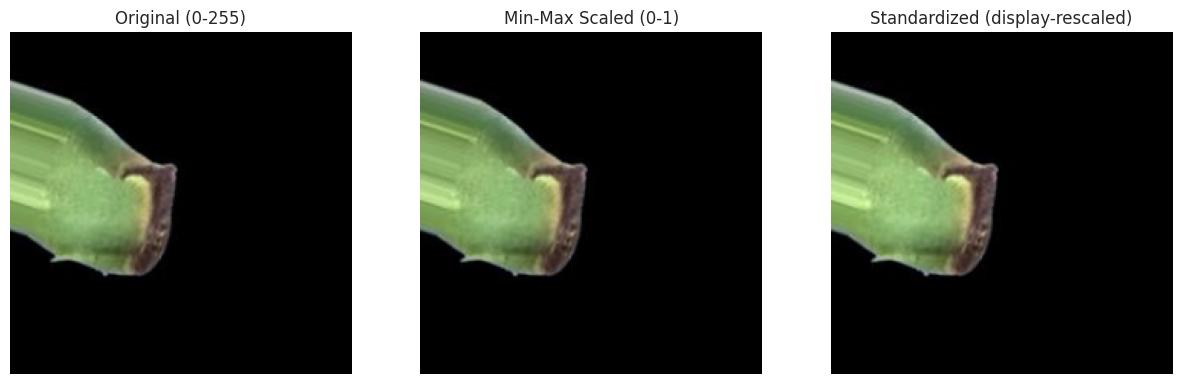

In [49]:
# ---- 1. Images side-by-side: Original vs Scaled vs Standardized ----
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_resized)
axes[0].set_title("Original (0-255)")
axes[0].axis('off')

axes[1].imshow(img_scaled)
axes[1].set_title("Min-Max Scaled (0-1)")
axes[1].axis('off')

# standardized images have negative values, so rescale just for display
img_std_display = (img_standardized - img_standardized.min()) / (img_standardized.max() - img_standardized.min())
axes[2].imshow(img_std_display)
axes[2].set_title("Standardized (display-rescaled)")
axes[2].axis('off')

<Figure size 640x480 with 0 Axes>

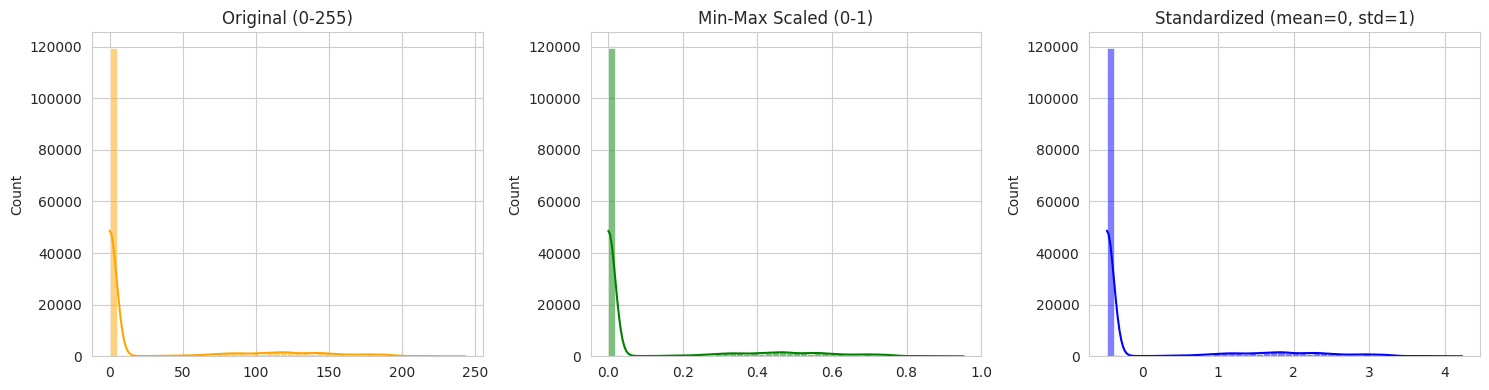

In [50]:
# standardized images have negative values, so rescale just for display
img_std_display = (img_standardized - img_standardized.min()) / (img_standardized.max() - img_standardized.min())
axes[2].imshow(img_std_display)
axes[2].set_title("Standardized (display-rescaled)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# ---- 2. Pixel distribution comparison using seaborn ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(img_resized.ravel(), bins=50, color='orange', ax=axes[0], kde=True)
axes[0].set_title("Original (0-255)")

sns.histplot(img_scaled.ravel(), bins=50, color='green', ax=axes[1], kde=True)
axes[1].set_title("Min-Max Scaled (0-1)")

sns.histplot(img_standardized.ravel(), bins=50, color='blue', ax=axes[2], kde=True)
axes[2].set_title("Standardized (mean=0, std=1)")

plt.tight_layout()
plt.show()



In [52]:
import pandas as pd

In [53]:
# ---- 3. Interactive comparison with plotly ----
df = pd.DataFrame({
    'pixel_value': np.concatenate([
        img_resized.ravel(),
        img_scaled.ravel(),
        img_standardized.ravel()
    ]),
    'type': (
        ['Original (0-255)'] * img_resized.size +
        ['Min-Max Scaled (0-1)'] * img_scaled.size +
        ['Standardized'] * img_standardized.size
    )
})

fig = px.histogram(df, x='pixel_value', color='type', facet_col='type',
                    nbins=50, title="Pixel Value Distribution: Before vs After Scaling")
fig.update_yaxes(matches=None)  # let each subplot scale independently
fig.show()